In [15]:
import warnings
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from rdkit import Chem
from rdkit.Chem import Descriptors

warnings.filterwarnings("ignore")

In [16]:
# Adapted from https://github.com/OpenFreeEnergy/cinnabar/blob/26eecb75bdbb5d7baf8798615feed16effe62abb/cinnabar/stats.py#L8
def bootstrap_statistic(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dy_true: Union[np.ndarray, None] = None,
    dy_pred: Union[np.ndarray, None] = None,
    ci: float = 0.95,
    statistic: str = "RMSE",
    nbootstrap: int = 100,
    plot_type: str = "dG",
    include_true_uncertainty: bool = False,
    include_pred_uncertainty: bool = False,
) -> dict:
    """
    Compute mean and confidence intervals of specified statistic.

    Parameters
    ----------
    y_true : ndarray with shape (N,)
        True values
    y_pred : ndarray with shape (N,)
        Predicted values
    dy_true : ndarray with shape (N,) or None
        Errors of true values. If None, the values are assumed to have no errors
    dy_pred : ndarray with shape (N,) or None
        Errors of predicted values. If None, the values are assumed to have no errors
    ci : float, optional, default=0.95
        Interval for confidence interval (CI)
    statistic : str
        Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','KTAU','RAE']
    nbootstrap : int, optional, default=1000
        Number of bootstrap samples
    plot_type : str, optional, default='dG'
        'dG' or 'ddG'
    include_true_uncertainty : bool, default False
        whether to account for the uncertainty in y_true when bootstrapping
    include_pred_uncertainty : bool, default False
        whether to account for the uncertainty in y_pred when bootstrapping

    Returns
    -------
    rmse_stats : dict of float
        'mean' : mean RMSE
        'stderr' : standard error
        'low' : low end of CI
        'high' : high end of CI
    """

    def compute_statistic(
        y_true_sample: np.ndarray, y_pred_sample: np.ndarray, statistic: str
    ):
        """Compute requested statistic.

        Parameters
        ----------
        y_true : ndarray with shape (N,)
            True values
        y_pred : ndarray with shape (N,)
            Predicted values
        statistic : str
            Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','RAE','KTAU']

        """

        def calc_RAE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            MAE = sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
            mean = np.mean(y_true_sample)
            MAD = np.sum([np.abs(mean - i) for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            return MAE / MAD

        def calc_RRMSE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            rmse = np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
            mean_exp = np.mean(y_true_sample)
            mds = np.sum([(mean_exp - i) ** 2 for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            rrmse = np.sqrt(rmse**2 / mds)
            return rrmse

        if statistic == "RMSE":
            return np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
        elif statistic == "MUE":
            return sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
        elif statistic == "MSE":
            # mean signed error
            return np.mean(y_pred_sample - y_true_sample)
        elif statistic == "R2":
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
                y_true_sample, y_pred_sample
            )
            return r_value**2
        elif statistic == "rho":
            return scipy.stats.pearsonr(y_true_sample, y_pred_sample)[0]
        elif statistic == "RAE":
            return calc_RAE(y_true_sample, y_pred_sample)
        elif statistic == "KTAU":
            return scipy.stats.kendalltau(y_true_sample, y_pred_sample)[0]
        else:
            raise Exception("unknown statistic '{}'".format(statistic))

    # not used?
    def unique_differences(x):
        """Compute all unique differences"""
        N = len(x)
        return np.array([(x[i] - x[j]) for i in range(N) for j in range(N) if (i != j)])

    if dy_true is None:
        dy_true = np.zeros_like(y_true)
    if dy_pred is None:
        dy_pred = np.zeros_like(y_pred)
    assert len(y_true) == len(y_pred)
    assert len(y_true) == len(dy_true)
    assert len(y_true) == len(dy_pred)
    sample_size = len(y_true)
    s_n = np.zeros(
        [nbootstrap], np.float64
    )  # s_n[n] is the statistic computed for bootstrap sample n
    for replicate in range(nbootstrap):
        y_true_sample = np.zeros_like(y_true)
        y_pred_sample = np.zeros_like(y_pred)
        for i, j in enumerate(
            np.random.choice(np.arange(sample_size), size=[sample_size], replace=True)
        ):
            stddev_true = np.fabs(dy_true[j]) if include_true_uncertainty else 0
            stddev_pred = np.fabs(dy_pred[j]) if include_pred_uncertainty else 0
            y_true_sample[i] = np.random.normal(
                loc=y_true[j], scale=stddev_true, size=1
            )
            y_pred_sample[i] = np.random.normal(
                loc=y_pred[j], scale=stddev_pred, size=1
            )
        s_n[replicate] = compute_statistic(y_true_sample, y_pred_sample, statistic)

    rmse_stats = dict()
    rmse_stats["mle"] = compute_statistic(y_true, y_pred, statistic)
    rmse_stats["stderr"] = np.std(s_n)
    rmse_stats["mean"] = np.mean(s_n)
    # TODO: Is there a canned method to do this?
    s_n = np.sort(s_n)
    low_frac = (1.0 - ci) / 2.0
    high_frac = 1.0 - low_frac
    rmse_stats["low"] = s_n[int(np.floor(nbootstrap * low_frac))]
    rmse_stats["high"] = s_n[int(np.ceil(nbootstrap * high_frac))]

    return rmse_stats

In [17]:
pd.ExcelFile("../../../data/final_paper.xlsx").sheet_names

['TRAIN-DS-DIELECTRIC',
 'TRAIN-DS-EMLE-SPECIES',
 'TRAIN-DS-MMVACUUMME',
 'TEST-DS-MMVACUUMME',
 'TEST-DS-EMLE-SPECIES']

In [18]:
df_emle = pd.read_excel(
    "../../../data/final_paper.xlsx", sheet_name="TRAIN-DS-EMLE-SPECIES", header=1
)
df_emle

,Molecule,MM FFs,ML potential,QM7-Species-Rep1,QM7-Species-Rep2,QM7-Species-Rep3,Bespoke-Iter1-Species-Rep1,Bespoke-Iter1-Species-Rep2,Bespoke-Iter1-Species-Rep3,Bespoke-Iter2-Species-Rep1,Bespoke-Iter2-Species-Rep2,Bespoke-Iter2-Species-Rep3,Patched-Iter1-Species-Rep1,Patched-Iter1-Species-Rep2,Patched-Iter1-Species-Rep3,Patched-Iter2-Species-Rep1,Patched-Iter2-Species-Rep2,Patched-Iter2-Species-Rep3
0,n-pentane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-1624.275111,-1624.259953,-1624.175950,-1624.026516,-1624.055813,-1624.011538,-1624.016641,-1624.030133,-1624.034849,-1624.196429,-1624.178957,-1624.175535,-1624.134049,-1624.188885,-1624.130743
1,n-octane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-2526.630640,-2526.570872,-2526.678427,-2526.322911,-2526.381230,-2526.324979,-2526.337098,-2526.287208,-2526.305736,-2526.604477,-2526.507374,-2526.539489,-2526.360627,-2526.470535,-2526.461490
2,benzene,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-1390.557711,-1390.547940,-1390.553603,-1391.141469,-1391.158267,-1391.150607,-1391.125731,-1391.107100,-1391.134763,-1390.974971,-1390.959869,-1390.950488,-1390.963266,-1390.968267,-1390.952082
3,naphthalene,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-2196.760893,-2196.772049,-2196.764521,-2197.297069,-2197.298737,-2197.333308,-2197.235215,-2197.323332,-2197.274913,-2196.798581,-2196.913699,-2196.862137,-2196.945848,-2196.909288,-2196.921366
4,water,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-229.247077,-229.245901,-229.206852,-235.566955,-235.508145,-235.545300,-235.548807,-235.652563,-235.622756,-233.776616,-233.763469,-233.786332,-233.443507,-233.479310,-233.450474
5,methanol,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-524.710608,-524.661516,-524.715409,-523.187193,-523.200196,-523.187782,-523.198046,-523.162558,-523.164381,-523.042790,-523.019465,-522.993039,-522.752428,-522.760594,-522.783525
6,o-cresol,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-1782.605859,-1782.661467,-1782.644295,-1781.788087,-1781.861962,-1781.862690,-1781.687859,-1781.662460,-1781.715538,-1781.447752,-1781.415159,-1781.404154,-1781.395446,-1781.408047,-1781.364657
7,aceticacid,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-768.699410,-768.716194,-768.775845,-764.158745,-764.124942,-764.386251,-764.027512,-764.215695,-764.065601,-763.344982,-763.513881,-763.299970,-763.323773,-763.129101,-763.292163
8,1_4-dioxane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-1395.548825,-1395.536641,-1395.539808,-1395.148823,-1395.060153,-1395.165467,-1395.210247,-1395.406860,-1395.172516,-1396.201101,-1396.131315,-1396.142635,-1395.978985,-1396.015533,-1395.998857
9,methylpentanoate,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-1990.082001,-1990.102670,-1990.018952,-1989.092661,-1989.053007,-1989.081230,-1989.024545,-1988.852033,-1988.967059,-1987.915386,-1987.899265,-1987.973719,-1987.675664,-1987.644800,-1987.592904


In [19]:
df = pd.read_excel(
    "../../../data/final_paper.xlsx", sheet_name="TRAIN-DS-MMVACUUMME", header=1
)
df

,Molecule,MM FFs,ML potential,MM-Rep1,MM-Rep2,MM-Rep3,Vacuum-Rep1,Vacuum-Rep2,Vacuum-Rep3,ME-Rep1,ME-Rep2,ME-Rep3
0,n-pentane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),2.724395,2.771186,2.668807,-1622.703454,-1622.722110,-1622.731169,-1622.716549,-1622.729876,-1622.667858
1,n-octane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),3.094562,3.089491,3.152947,-2524.292917,-2524.274100,-2524.300537,-2524.285710,-2524.366838,-2524.381999
2,benzene,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-0.915510,-0.955145,-1.041780,-1390.125924,-1390.123216,-1390.119034,-1390.325225,-1390.300813,-1390.321332
3,naphthalene,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-3.568862,-3.558796,-3.510536,-2196.969381,-2196.948231,-2196.950548,-2196.959261,-2196.914793,-2196.938929
4,water,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-6.415669,-6.386042,-6.398134,-231.619755,-231.619789,-231.614161,-232.068548,-232.053581,-232.058900
5,methanol,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-3.887195,-3.904854,-3.911495,-520.366858,-520.371289,-520.355546,-520.207448,-520.203285,-520.209332
6,o-cresol,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-5.350394,-5.361286,-5.404287,-1778.872888,-1778.888010,-1778.891090,-1780.113372,-1780.039554,-1780.046364
7,aceticacid,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-6.974250,-6.883560,-6.922687,-760.663608,-760.674895,-760.657271,-760.657452,-760.554795,-760.588866
8,1_4-dioxane,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-3.897217,-3.877977,-3.841539,-1393.933804,-1393.972628,-1393.940700,-1393.872692,-1393.886404,-1393.871344
9,methylpentanoate,OpenFF-2.0.0/TIP3P,MACE-OFF23(S),-3.095711,-3.137685,-3.056337,-1986.210272,-1986.206271,-1986.219876,-1986.186428,-1986.144141,-1986.147793


In [20]:
QM7_COLS = ["QM7-Species-Rep1", "QM7-Species-Rep2", "QM7-Species-Rep3"]
BESPOKE_ITER_1_COLS = [
    "Bespoke-Iter1-Species-Rep1",
    "Bespoke-Iter1-Species-Rep2",
    "Bespoke-Iter1-Species-Rep3",
]
BESPOKE_ITER_2_COLS = [
    "Bespoke-Iter2-Species-Rep1",
    "Bespoke-Iter2-Species-Rep2",
    "Bespoke-Iter2-Species-Rep3",
]
PATCHED_ITER_1_COLS = [
    "Patched-Iter1-Species-Rep1",
    "Patched-Iter1-Species-Rep2",
    "Patched-Iter1-Species-Rep3",
]
PATCHED_ITER_2_COLS = [
    "Patched-Iter2-Species-Rep1",
    "Patched-Iter2-Species-Rep2",
    "Patched-Iter2-Species-Rep3",
]
MM_COLS = ["MM-Rep1", "MM-Rep2", "MM-Rep3"]
VACUUM_COLS = ["Vacuum-Rep1", "Vacuum-Rep2", "Vacuum-Rep3"]
ME_COLS = ["ME-Rep1", "ME-Rep2", "ME-Rep3"]

EXP_MEAN = [
    2.33,
    2.89,
    -0.87,
    -2.39,
    -6.31,
    -5.11,
    -5.87,
    -6.7,
    -5.05,
    -2.57,
    -3.91,
    -3.53,
    -2.22,
    -9.51,
    -3.89,
    -4.7,
    -5.49,
    -10.9,
    -1.05,
    -2.73,
]

SMILES = [
    "CCCCC",
    "CCCCCCCC",
    "c1ccccc1",
    "c1ccc2ccccc2c1",
    "O",
    "CO",
    "Cc1ccccc1O",
    "CC(O)=O",
    "C1COCCO1",
    "CCCCC(=O)OC",
    "COC(=O)c1ccccc1",
    "CCCC(C)=O",
    "CCOc1ccccc1",
    "Oc1cccc(C=O)c1",
    "CC#N",
    "c1ccncc1",
    "Nc1ccccc1",
    "NC(=O)c1ccccc1",
    "CCCS",
    "CSc1ccccc1",
]

# 0.2 kcal/mol according to: https://comp.chem.umn.edu/mnsol/MNSol-v2012_Manual.pdf
EXP_STD = [0.2] * len(EXP_MEAN)

MM = df[MM_COLS]
VACUUM = df[VACUUM_COLS]
ME = df[ME_COLS]

QM7 = df_emle[QM7_COLS]
BESPOKE_ITER_1 = df_emle[BESPOKE_ITER_1_COLS]
BESPOKE_ITER_2 = df_emle[BESPOKE_ITER_2_COLS]
PATCHED_ITER_1 = df_emle[PATCHED_ITER_1_COLS]
PATCHED_ITER_2 = df_emle[PATCHED_ITER_2_COLS]

In [21]:
dG_MM_MEAN = MM.mean(axis=1)
dG_ME_MEAN = MM.mean(axis=1) + ME.mean(axis=1) - VACUUM.mean(axis=1)
dG_QM7_MEAN = MM.mean(axis=1) + QM7.mean(axis=1) - VACUUM.mean(axis=1)
dG_BESPOKE_ITER_1_MEAN = (
    MM.mean(axis=1) + BESPOKE_ITER_1.mean(axis=1) - VACUUM.mean(axis=1)
)
dG_BESPOKE_ITER_2_MEAN = (
    MM.mean(axis=1) + BESPOKE_ITER_2.mean(axis=1) - VACUUM.mean(axis=1)
)
dG_PATCHED_ITER_1_MEAN = (
    MM.mean(axis=1) + PATCHED_ITER_1.mean(axis=1) - VACUUM.mean(axis=1)
)
dG_PATCHED_ITER_2_MEAN = (
    MM.mean(axis=1) + PATCHED_ITER_2.mean(axis=1) - VACUUM.mean(axis=1)
)

# Uncertainty (propag)
dG_MM_STD = MM.std(axis=1)
dG_ME_STD = np.sqrt(MM.std(axis=1) ** 2 + ME.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2)
dG_QM7_STD = np.sqrt(
    MM.std(axis=1) ** 2 + QM7.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2
)
dG_BESPOKE_ITER_1_STD = np.sqrt(
    MM.std(axis=1) ** 2 + BESPOKE_ITER_1.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2
)
dG_BESPOKE_ITER_2_STD = np.sqrt(
    MM.std(axis=1) ** 2 + BESPOKE_ITER_2.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2
)
dG_PATCHED_ITER_1_STD = np.sqrt(
    MM.std(axis=1) ** 2 + PATCHED_ITER_1.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2
)
dG_PATCHED_ITER_2_STD = np.sqrt(
    MM.std(axis=1) ** 2 + PATCHED_ITER_2.std(axis=1) ** 2 + VACUUM.std(axis=1) ** 2
)

# Sample std error : t_student_coeff * std / sqrt(3)
t_student_coeff = 4.303  # 2.920
dG_MM_ERROR = t_student_coeff * dG_MM_STD / np.sqrt(3)
dG_ME_ERROR = t_student_coeff * dG_ME_STD / np.sqrt(3)
dG_QM7_ERROR = t_student_coeff * dG_QM7_STD / np.sqrt(3)
dG_BESPOKE_ITER_1_ERROR = t_student_coeff * dG_BESPOKE_ITER_1_STD / np.sqrt(3)
dG_BESPOKE_ITER_2_ERROR = t_student_coeff * dG_BESPOKE_ITER_2_STD / np.sqrt(3)
dG_PATCHED_ITER_1_ERROR = t_student_coeff * dG_PATCHED_ITER_1_STD / np.sqrt(3)
dG_PATCHED_ITER_2_ERROR = t_student_coeff * dG_PATCHED_ITER_2_STD / np.sqrt(3)

df_data_mean = pd.DataFrame(
    {
        "EXP": EXP_MEAN,
        "OpenFF/TIP3P": dG_MM_MEAN,
        "ME ML/MM": dG_ME_MEAN,
        "General Model": dG_QM7_MEAN,
        #'BESPOKE_ITER_1': dG_BESPOKE_ITER_1_MEAN,
        "Bespoke Model": dG_BESPOKE_ITER_2_MEAN,
        #'PATCHED_ITER_1': dG_PATCHED_ITER_1_MEAN,
        "Patched Model": dG_PATCHED_ITER_2_MEAN,
    }
)

df_data_std = pd.DataFrame(
    {
        "EXP": EXP_STD,
        "OpenFF/TIP3P": dG_MM_STD,
        "ME ML/MM": dG_ME_STD,
        "General Model": dG_QM7_STD,
        "Bespoke Model": dG_BESPOKE_ITER_2_STD,
        "Patched Model": dG_PATCHED_ITER_2_STD,
        # 'Bespoke Model': dG_BESPOKE_ITER_1_STD,
        # 'Patched Model': dG_PATCHED_ITER_1_STD,
    }
)

df_data_error = pd.DataFrame(
    {
        "EXP": EXP_STD,
        "OpenFF/TIP3P": dG_MM_ERROR,
        "ME ML/MM": dG_ME_ERROR,
        "General Model": dG_QM7_ERROR,
        "Bespoke Model": dG_BESPOKE_ITER_2_ERROR,
        "Patched Model": dG_PATCHED_ITER_2_ERROR,
        # 'Bespoke Model': dG_BESPOKE_ITER_1_ERROR,
        # 'Patched Model': dG_PATCHED_ITER_1_ERROR,
    }
)

# Compute molecular weights with hydrogens
weights = []
for smi in SMILES:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)  
        mw = Descriptors.MolWt(mol)  
        weights.append(mw)

df_data_error['MolecularWeight'] = weights

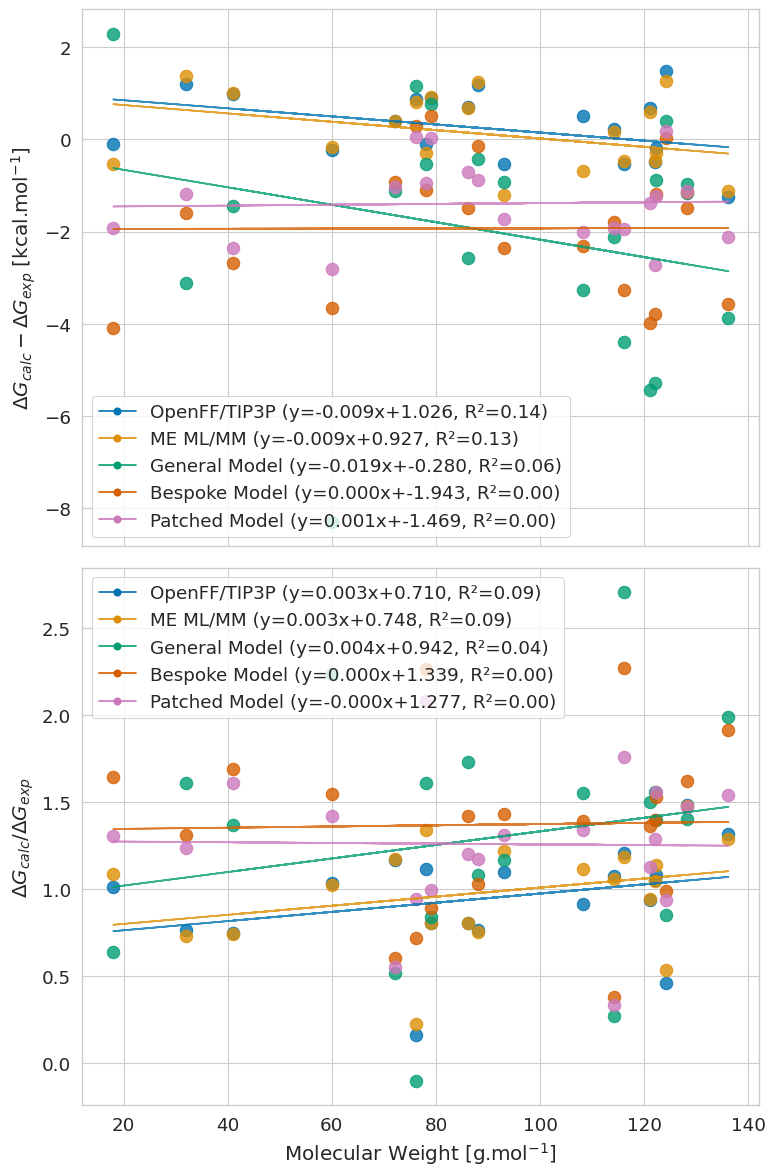

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress
from matplotlib.lines import Line2D

sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)

models = ["OpenFF/TIP3P", "ME ML/MM", "General Model", "Bespoke Model", "Patched Model"]
df_signed = pd.DataFrame()
df_relative = pd.DataFrame()

df_signed["MolecularWeight"] = df_data_error["MolecularWeight"]
df_relative["MolecularWeight"] = df_data_error["MolecularWeight"]

for model in models:
    df_signed[model] = df_data_mean[model] - df_data_mean["EXP"]
    df_relative[model] = df_data_mean[model] / df_data_mean["EXP"]

fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

palette = sns.color_palette("colorblind", n_colors=len(models))

for i, model in enumerate(models):
    x = df_signed["MolecularWeight"]
    y = df_signed[model]

    # Scatter
    axes[0].scatter(x, y, s=80, alpha=0.8, color=palette[i])

    # Regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    axes[0].plot(x, y_fit, alpha=0.8, color=palette[i])

# Axes formatting
axes[0].set_ylabel("$\\Delta G_{calc} - \\Delta G_{exp}$ [kcal.mol$^{-1}$]")
axes[0].grid(True)

legend_elements_top = [
    Line2D([0], [0], color=palette[i], marker='o', linestyle='-', 
           label=f"{models[i]} (y={linregress(df_signed['MolecularWeight'], df_signed[models[i]]).slope:.3f}x+{linregress(df_signed['MolecularWeight'], df_signed[models[i]]).intercept:.3f}, R²={linregress(df_signed['MolecularWeight'], df_signed[models[i]]).rvalue**2:.2f})")
    for i in range(len(models))
]
axes[0].legend(handles=legend_elements_top)

for i, model in enumerate(models):
    x = df_relative["MolecularWeight"]
    y = df_relative[model]

    axes[1].scatter(x, y, s=80, alpha=0.8, color=palette[i])
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    axes[1].plot(x, y_fit, alpha=0.8, color=palette[i])

axes[1].set_xlabel("Molecular Weight [g.mol$^{-1}$]")
axes[1].set_ylabel(r"$\Delta G_{calc} / \Delta G_{exp}$")
axes[1].grid(True)

legend_elements_bottom = [
    Line2D([0], [0], color=palette[i], marker='o', 
           label=f"{models[i]} (y={linregress(df_relative['MolecularWeight'], df_relative[models[i]]).slope:.3f}x+{linregress(df_relative['MolecularWeight'], df_relative[models[i]]).intercept:.3f}, R²={linregress(df_relative['MolecularWeight'], df_relative[models[i]]).rvalue**2:.2f})")
    for i in range(len(models))
]
axes[1].legend(handles=legend_elements_bottom)

plt.tight_layout()
plt.savefig("error_vs_molecular_weight_signed_relative_clean_legend.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()
